In [1]:
# importing library
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.decomposition import PCA


In [2]:
# Load the dataset 
df_scaled = pd.read_csv('../data/heart_scaled.csv')
num_cols = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']

# Apply PCA for dimensionality reduction
pca = PCA(n_components=4, random_state=42)
X_pca = pca.fit_transform(df_scaled[num_cols])

# Explained variance
explained_variance = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)
print("Explained Variance per PC:", explained_variance.tolist())
print("Cumulative Variance:", cumulative_variance.tolist())

Explained Variance per PC: [0.39960212103781917, 0.2061908464304753, 0.18023099607159795, 0.12248085738202552]
Cumulative Variance: [0.39960212103781917, 0.6057929674682945, 0.7860239635398925, 0.908504820921918]


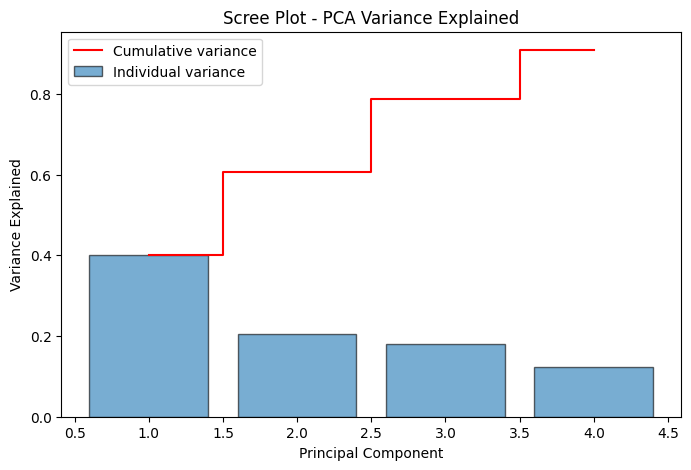

In [8]:
# 6.scree variance plot
plt.figure(figsize=(8,5))
plt.bar(range(1, len(explained_variance)+1), explained_variance, alpha=0.6, label='Individual variance',edgecolor='black')
plt.step(range(1, len(cumulative_variance)+1), cumulative_variance, where='mid', color='red', label='Cumulative variance')
plt.xlabel('Principal Component')
plt.ylabel('Variance Explained')
plt.title('Scree Plot - PCA Variance Explained')
plt.legend()
plt.show()

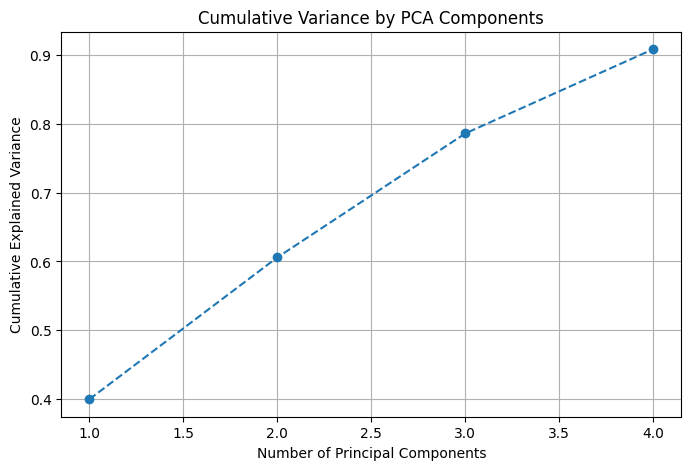

In [4]:
#cumulative variance plot
plt.figure(figsize=(8,5))
plt.plot(range(1,len(cumulative_variance)+1), cumulative_variance, marker='o', linestyle='--')
plt.xlabel('Number of Principal Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('Cumulative Variance by PCA Components')
plt.grid(True)
plt.show()


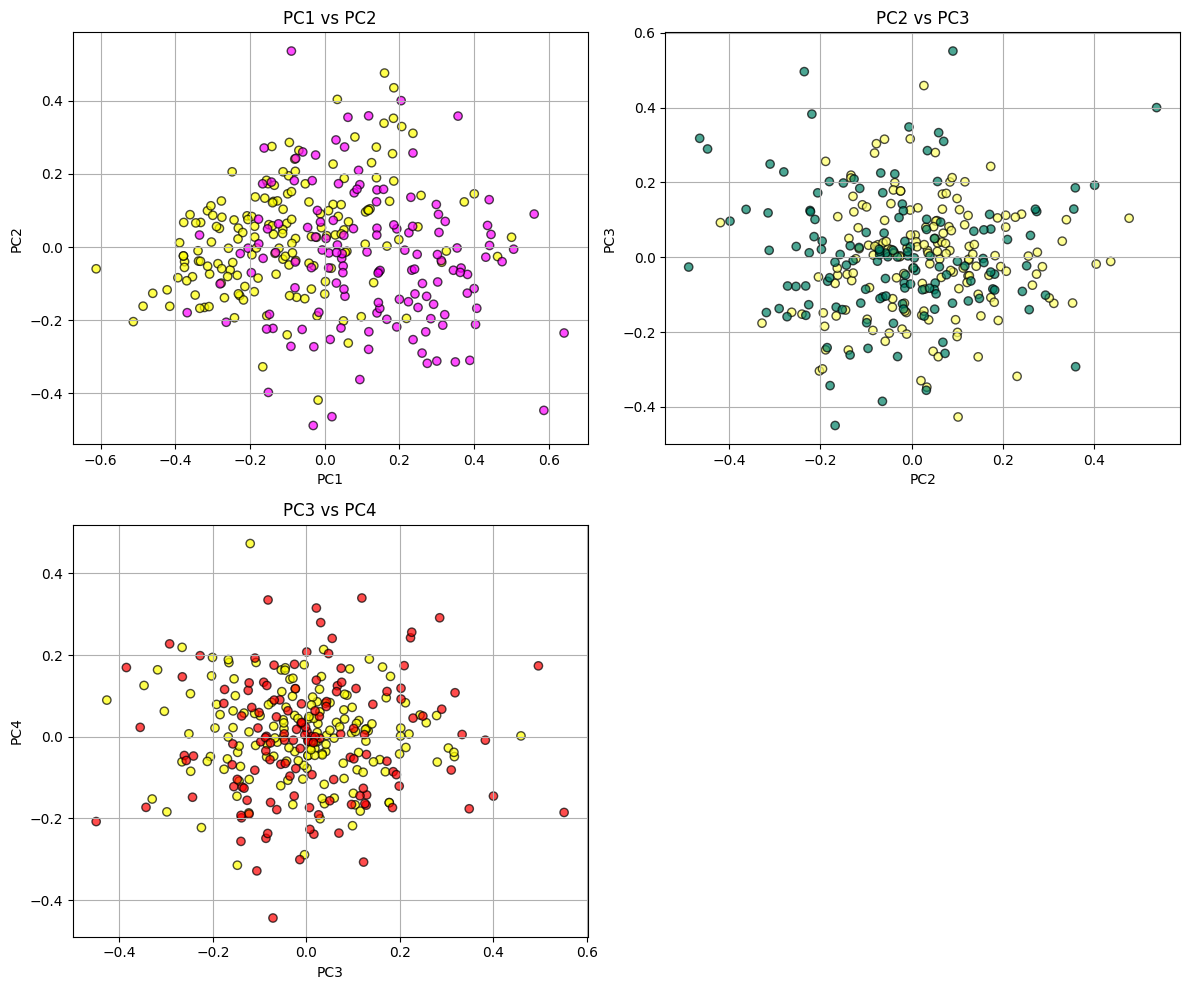

In [7]:
# some scatter plots
fig, axes = plt.subplots(2,2, figsize=(12,10))
pcs = [0,1,2,3]  
colors = ['spring', 'summer', 'autumn']

for i, ax in enumerate(axes.flat):
    if i < len(pcs)-1:
        ax.scatter(X_pca[:, pcs[i]], X_pca[:, pcs[i+1]], 
        c=df_scaled['target'], cmap=colors[i], alpha=0.7,edgecolor='black')
        ax.set_xlabel(f'PC{pcs[i]+1}')
        ax.set_ylabel(f'PC{pcs[i+1]+1}')
        ax.set_title(f'PC{pcs[i]+1} vs PC{pcs[i+1]+1}')
    else:
        ax.axis('off')  
    ax.grid()  
plt.tight_layout()
plt.show()




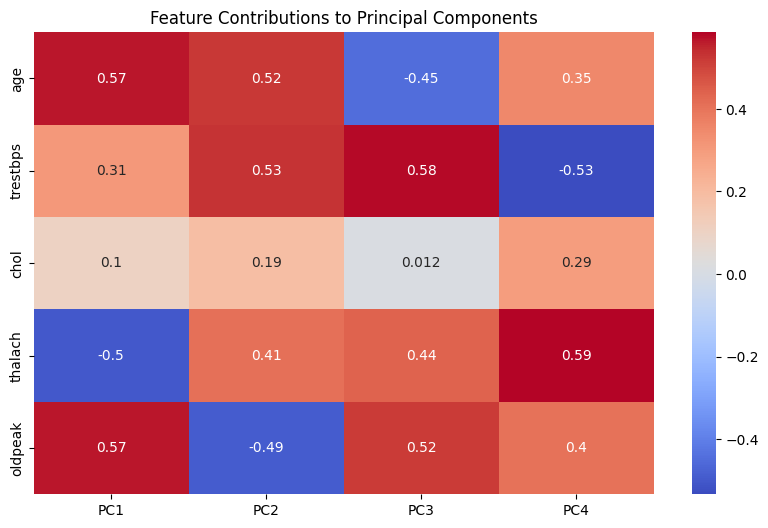

In [6]:
# heatmap between feature and pca component
loadings = pd.DataFrame(pca.components_.T, index=num_cols, columns=[f'PC{i+1}' for i in range(pca.n_components_)])
plt.figure(figsize=(10,6))
sns.heatmap(loadings, annot=True, cmap='coolwarm')
plt.title('Feature Contributions to Principal Components')
plt.show()
